In [19]:
import numpy as np
import pandas as pd
from itertools import combinations
 
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from scipy.stats import kendalltau
import krippendorff

In [20]:
df1 = pd.read_csv("./data/ifbench_annotation_A.csv")
df2 = pd.read_csv("./data/ifbench_annotation_B.csv")
df3 = pd.read_csv("./data/ifbench_annotation_C.csv")

In [21]:
annotators = {
    "A1": df1,
    "A2": df2,
    "A3": df3,
}

In [22]:
N_SHARED = 30
SCORE_COLS = ["winner"]
 
# Shared block (first 100 rows) per annotator -> should be item-aligned
shared = {name: df.iloc[:N_SHARED].reset_index(drop=True) for name, df in annotators.items()}

In [23]:
unique = {name: df.iloc[N_SHARED:].reset_index(drop=True) for name, df in annotators.items()}

In [24]:
names = list(annotators.keys())
pairs = list(combinations(names, 2))
n_unique_each = len(unique[names[0]]) 
names, pairs, n_unique_each

(['A1', 'A2', 'A3'], [('A1', 'A2'), ('A1', 'A3'), ('A2', 'A3')], 10)

In [25]:
def absolute_agreement(shared_dict, col):
    rows = []
    for a, b in pairs:
        s1 = shared_dict[a][col]
        s2 = shared_dict[b][col]
        agree = (s1 == s2).mean()
        rows.append({"pair": f"{a}-{b}", "column": col, "absolute_agreement": agree})
    return pd.DataFrame(rows)
 
 
abs_agree = absolute_agreement(shared, "winner")
 
print("=== Absolute (exact-match) agreement: winner ===")
print(abs_agree.to_string(index=False))


=== Absolute (exact-match) agreement: winner ===
 pair column  absolute_agreement
A1-A2 winner            0.966667
A1-A3 winner            0.933333
A2-A3 winner            0.900000


In [26]:
winner_matrix = np.column_stack([shared[n]["winner"].values for n in names])
agg_table, categories = aggregate_raters(winner_matrix)
fleiss_refusal = fleiss_kappa(agg_table, method="fleiss")
 
print(f"\n=== Fleiss' kappa (winner, 3 annotators, {N_SHARED} items) ===")
print(f"Categories: {categories}")
print(f"Fleiss kappa: {fleiss_refusal:.4f}")


=== Fleiss' kappa (winner, 3 annotators, 30 items) ===
Categories: ['A' 'B']
Fleiss kappa: 0.8661


In [27]:
def pairwise_cohen_kappa(shared_dict, col):
    rows = []
    for a, b in pairs:
        k = cohen_kappa_score(shared_dict[a][col], shared_dict[b][col])
        rows.append({"pair": f"{a}-{b}", "column": col, "cohen_kappa": k})
    return pd.DataFrame(rows)
 
 
cohen_refusal = pairwise_cohen_kappa(shared, "winner")
print("\n=== Cohen's kappa, pairwise: winner ===")
print(cohen_refusal.to_string(index=False))


=== Cohen's kappa, pairwise: winner ===
 pair column  cohen_kappa
A1-A2 winner     0.932735
A1-A3 winner     0.866667
A2-A3 winner     0.800000


In [28]:
import statistics

shared_agg = shared[names[0]][["prompt", "Model A", "Model B"]].copy()
for col in SCORE_COLS:
    score_stack = np.column_stack([shared[n][col].values for n in names])
    shared_agg[col] = [statistics.mode(x) for x in score_stack]
shared_agg["source"] = "shared_mode_of_3"
 
# Unique blocks: keep each annotator's own ratings as-is
unique_agg_parts = []
for n in names:
    part = unique[n][["prompt", "Model A", "Model B"] + SCORE_COLS].copy()
    part["source"] = f"unique_{n}"
    unique_agg_parts.append(part)
 
aggregate_df = pd.concat([shared_agg] + unique_agg_parts, ignore_index=True)
 
print(f"\n=== Aggregate DataFrame ===")
print(f"Total rows: {len(aggregate_df)} (expected {N_SHARED + n_unique_each * len(names)})")
aggregate_df.head()


=== Aggregate DataFrame ===
Total rows: 60 (expected 60)


,prompt,Model A,Model B,winner,source
0,Mention at least 18 different person names in ...,"Oh, hello there, sweetie! You've come to the ...","*Claps hands together, sending a tiny cloud of...",B,shared_mode_of_3
1,Come up with a name for a brand that consists ...,NeonFlux \nGlowPulse \nLumenShift \nVividRu...,NeonFlux \nLumenPulse \nGlowGrid \nPixelVib...,A,shared_mode_of_3
2,"Translate to Russian (with romanization) ""Thos...",This is a rather... poetic description of a te...,Sit down. You want a translation that carries ...,A,shared_mode_of_3
3,Each sentence in your response must contain ex...,"Such a concoction, devoid of antihistamines, w...",Such trivialities bore me.\nYour mortal ailmen...,A,shared_mode_of_3
4,No two consecutive words can share the same fi...,"Ah, a most intriguing question, and one that d...","Professor, you have posed a question that stri...",A,shared_mode_of_3


In [29]:
aggregate_df.to_csv("data/ifbench_aggregate.csv", index=False)

In [30]:
gemini_ratings = pd.read_json("ratings/gemini-3.1-pro-preview-ifbench_ratings_validate.jsonl", lines=True)

In [31]:
from ast import literal_eval

gemini_ratings["response"] = gemini_ratings.response.apply(lambda x: literal_eval(x["candidates"][0]["content"]["parts"][0]["text"]) if "candidates" in x else x)

In [32]:
gemini_ratings = gemini_ratings.join(pd.DataFrame(gemini_ratings['response'].tolist()))[["key", "winner"]]

In [33]:
gemini_ratings.sort_values("key", inplace=True)

In [34]:
assert len(gemini_ratings) == len(aggregate_df), "gemini_ratings must match aggregate_df row-for-row"
 
# Cohen's kappa: refusal_score (binary, nominal) - human aggregate vs Gemini
kappa_refusal_vs_gemini = cohen_kappa_score(
    aggregate_df["winner"], gemini_ratings["winner"]
)
print(f"\n=== Cohen's kappa: aggregate vs Gemini (winner) ===")
print(f"Cohen kappa: {kappa_refusal_vs_gemini:.4f}")

(gemini_ratings["winner"].values == aggregate_df["winner"].values).mean()


=== Cohen's kappa: aggregate vs Gemini (winner) ===
Cohen kappa: 0.4258


np.float64(0.7333333333333333)

In [37]:
samples = pd.read_csv("data/ifbench_to_annotate.csv")

In [17]:
from sklearn.metrics import confusion_matrix
 
winner_labels = sorted(set(aggregate_df["winner"]) | set(gemini_ratings["winner"]))
cm_winner_raw = confusion_matrix(
    aggregate_df["winner"], gemini_ratings["winner"], labels=winner_labels
)


print("\n=== Confusion matrix: winner_score (human aggregate vs Gemini) ===")
print(pd.DataFrame(cm_winner_raw, index=winner_labels, columns=winner_labels))



=== Confusion matrix: winner_score (human aggregate vs Gemini) ===
    A   B
A  30   8
B   8  14


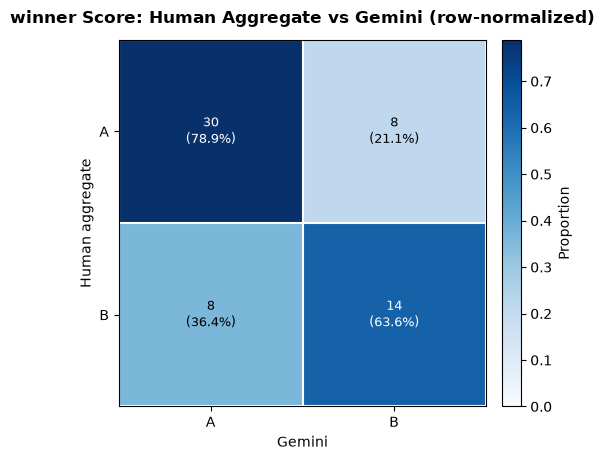

In [18]:
import matplotlib.pyplot as plt
 
 
def plot_confusion_matrix(cm, labels, title, true_name="Human aggregate", pred_name="Gemini",
                           normalize="pred", cmap="Blues", save_path=None):
    """
    cm: raw count confusion matrix (rows = true/human, cols = predicted/gemini)
    normalize: 'true' (row-normalize, i.e. % within each human category),
               'pred' (column-normalize), 'all' (normalize by grand total), or None (raw counts)
    """
    cm = np.asarray(cm, dtype=float)
 
    if normalize == "true":
        with np.errstate(all="ignore"):
            norm_cm = cm / cm.sum(axis=1, keepdims=True)
    elif normalize == "pred":
        with np.errstate(all="ignore"):
            norm_cm = cm / cm.sum(axis=0, keepdims=True)
    elif normalize == "all":
        norm_cm = cm / cm.sum()
    else:
        norm_cm = cm
 
    norm_cm = np.nan_to_num(norm_cm)
 
    fig, ax = plt.subplots(figsize=(1.1 * len(labels) + 3, 1.1 * len(labels) + 2.5))
    im = ax.imshow(norm_cm, cmap=cmap, vmin=0, vmax=norm_cm.max() if normalize else None)
 
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel(pred_name)
    ax.set_ylabel(true_name)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
 
    # Annotate each cell with count and (if normalized) percentage
    thresh = norm_cm.max() / 2.0 if norm_cm.max() > 0 else 0.5
    for i in range(len(labels)):
        for j in range(len(labels)):
            count = int(cm[i, j])
            text_color = "white" if norm_cm[i, j] > thresh else "black"
            if normalize:
                pct = norm_cm[i, j] * 100
                label = f"{count}\n({pct:.1f}%)"
            else:
                label = f"{count}"
            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=9)
 
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Proportion" if normalize else "Count")
 
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
 
    fig.tight_layout()
    plt.show()
 
 
plot_confusion_matrix(
    cm_winner_raw, winner_labels,
    title="winner Score: Human Aggregate vs Gemini (row-normalized)",
    normalize="true",
)
